In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_food_orders_cleaned = pd.read_csv("../data/cleaned/grab_food_orders_cleaned.csv", parse_dates=["order_time", "driver_arrived_time", "completed_time"])
df_merchants_cleaned = pd.read_csv("../data/cleaned/grab_merchants_cleaned.csv")
df_users_cleaned = pd.read_csv("../data/cleaned/users_cleaned.csv")

In [6]:
df_food_orders_cleaned.head(3)

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,promo_discount_sentinel,...,order_day,order_day_name,driver_arrived_year,driver_arrived_month,driver_arrived_day,driver_arrived_day_name,completed_year,completed_month,completed_day,completed_day_name
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,Not Applicable,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00,False,...,21,Thursday,2023.0,12.0,21.0,Thursday,2023.0,12.0,21.0,Thursday
1,GF-ORD-00000002,GF-07698,GB-019520,Cancelled,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT,False,...,20,Wednesday,2023.0,12.0,20.0,Wednesday,NaN,NaN,NaN,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,Cancelled,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaT,False,...,18,Sunday,2024.0,2.0,18.0,Sunday,NaN,NaN,NaN,NaN


In [7]:
df_food_orders_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   order_id                 300000 non-null  str           
 1   merchant_id              300000 non-null  str           
 2   user_id                  300000 non-null  str           
 3   order_status             300000 non-null  str           
 4   promo_discount           300000 non-null  int64         
 5   cancel_reason            300000 non-null  str           
 6   order_time               300000 non-null  datetime64[us]
 7   driver_arrived_time      270320 non-null  datetime64[us]
 8   completed_time           240093 non-null  datetime64[us]
 9   promo_discount_sentinel  300000 non-null  bool          
 10  order_year               300000 non-null  int64         
 11  order_month              300000 non-null  int64         
 12  order_day                30

In [9]:
df_food_orders_cleaned.shape

(300000, 22)

In [34]:
# persentase tiap order status
df_food_orders_cleaned["order_status"].value_counts(normalize=True) * 100

order_status
Completed    80.031
Cancelled    14.953
Failed        5.016
Name: proportion, dtype: float64

In [32]:
anomaly = df_food_orders_cleaned[(df_food_orders_cleaned["order_status"] == "Completed") & (df_food_orders_cleaned["driver_arrived_time"] >= df_food_orders_cleaned["completed_time"])]

#pct complete sebelum arrived
pct = len(anomaly) / len(df_food_orders_cleaned)
print(f"{pct:.2%}")

3.20%


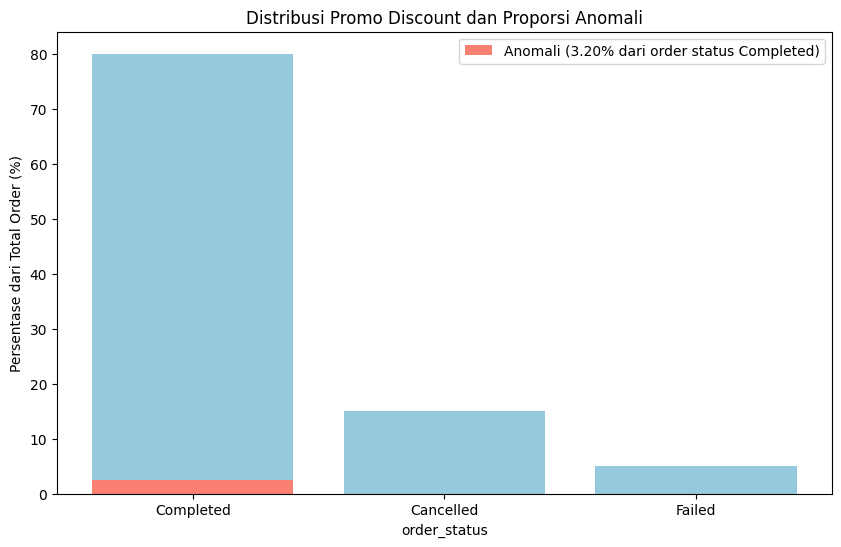

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Siapkan data untuk ringkasan promo
status_counts = df_food_orders_cleaned['order_status'].value_counts(normalize=True) * 100
status_df = status_counts.reset_index()
status_df.columns = ['order_status', 'percentage']

# 2. Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=status_df, x='order_status', y='percentage', color='skyblue')

# Tambahkan label anomali pada batang 30000
plt.bar(x=0, height=3.20 * (status_counts["Completed"]/100), color='salmon', label='Anomali (3.20% dari order status Completed)')

plt.title('Distribusi Promo Discount dan Proporsi Anomali')
plt.ylabel('Persentase dari Total Order (%)')
plt.legend()
plt.show()

In [ ]:
df_food_orders_cleaned.value_counts(subset="promo_discount")

promo_discount
0        118203
10000     57388
20000     43028
15000     42892
30000     38489
Name: count, dtype: int64

In [ ]:
# persentase order dgn prom 30000 per total order
df_food_orders_cleaned["promo_discount"].value_counts(normalize=True) * 100

promo_discount
0        39.401000
10000    19.129333
20000    14.342667
15000    14.297333
30000    12.829667
Name: proportion, dtype: float64

In [ ]:
anomaly.value_counts(subset="promo_discount")

promo_discount
30000    9603
Name: count, dtype: int64

In [ ]:
# diketahui semua anomaly pakai promo disc 30000
#persentase promo discount anomaly thd order yg promo diskon 30000
pct = len(anomaly) / len(df_food_orders_cleaned[df_food_orders_cleaned["promo_discount"] == 30000])
print(f"{pct:.2%}")

24.95%


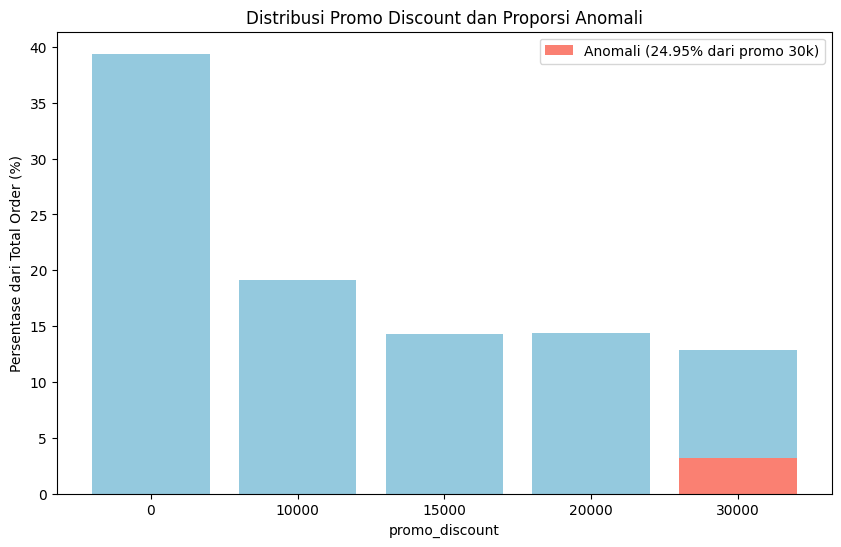

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Siapkan data untuk ringkasan promo
promo_counts = df_food_orders_cleaned['promo_discount'].value_counts(normalize=True) * 100
promo_df = promo_counts.reset_index()
promo_df.columns = ['promo_discount', 'percentage']

# 2. Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=promo_df, x='promo_discount', y='percentage', color='skyblue')

# Tambahkan label anomali pada batang 30000
plt.bar(x=4, height=24.95 * (promo_counts[30000]/100), color='salmon', label='Anomali (24.95% dari promo 30k)')

plt.title('Distribusi Promo Discount dan Proporsi Anomali')
plt.ylabel('Persentase dari Total Order (%)')
plt.legend()
plt.show()

Arrival Time > Completed Time x Promo Discount

**Insight 1:**
Terdapat 9.603 (3.20% dari total order) completed order yang memiliki completion time lebih awal daripada driver arrival time, yang mengindikasikan adanya inkonsistensi timestamp atau potensi manipulasi proses transaksi.

**Insight 2:**
Seluruh order anomali memanfaatkan promo dengan nilai subsidi Rp30.000.

**Insight 3:**
Potensi subsidi yang terekspos pada transaksi anomali mencapai Rp288 juta. (9603 x 30000)

**Insight 4**
Sebanyak 24.95% dari 12.82% order yang menggunakan promo disc 30000 memiliki completion time lebih awal daripada driver arrival time 

Apakah 9603 order ini pure anomali atau bug?

In [14]:
anomaly["time_diff"] = anomaly["driver_arrived_time"] - anomaly["completed_time"]
anomaly.head(3)

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,promo_discount_sentinel,...,order_day_name,driver_arrived_year,driver_arrived_month,driver_arrived_day,driver_arrived_day_name,completed_year,completed_month,completed_day,completed_day_name,time_diff
7,GF-ORD-00000008,GF-05908,GB-004497,Completed,30000,Not Applicable,2023-12-29 16:39:00,2023-12-29 16:58:00,2023-12-29 16:48:00,False,...,Friday,2023.0,12.0,29.0,Friday,2023.0,12.0,29.0,Friday,0 days 00:10:00
12,GF-ORD-00000013,GF-05000,GB-003623,Completed,30000,Not Applicable,2024-01-03 10:14:00,2024-01-03 10:24:00,2024-01-03 10:19:00,False,...,Wednesday,2024.0,1.0,3.0,Wednesday,2024.0,1.0,3.0,Wednesday,0 days 00:05:00
24,GF-ORD-00000025,GF-07570,GB-013509,Completed,30000,Not Applicable,2024-03-12 10:43:00,2024-03-12 10:53:00,2024-03-12 10:45:00,False,...,Tuesday,2024.0,3.0,12.0,Tuesday,2024.0,3.0,12.0,Tuesday,0 days 00:08:00


In [ ]:
anomaly["time_diff"].describe()

count                      9603
mean     0 days 00:09:31.521399
std      0 days 00:02:52.751985
min             0 days 00:05:00
25%             0 days 00:07:00
50%             0 days 00:10:00
75%             0 days 00:12:00
max             0 days 00:14:00
Name: time_diff, dtype: object

Q2: dari 9603 anomali merchant mana yang paling banyak muncul



In [25]:
df_food_merchant = anomaly.merge(df_merchants_cleaned, on="merchant_id")
df_food_merchant.head(3)

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,promo_discount_sentinel,...,driver_arrived_month,driver_arrived_day,driver_arrived_day_name,completed_year,completed_month,completed_day,completed_day_name,merchant_name,cuisine_type,city
0,GF-ORD-00000008,GF-05908,GB-004497,Completed,30000,Not Applicable,2023-12-29 16:39:00,2023-12-29 16:58:00,2023-12-29 16:48:00,False,...,12.0,29.0,Friday,2023.0,12.0,29.0,Friday,Resto GrabMantap 5907,Beverages,Medan
1,GF-ORD-00000013,GF-05000,GB-003623,Completed,30000,Not Applicable,2024-01-03 10:14:00,2024-01-03 10:24:00,2024-01-03 10:19:00,False,...,1.0,3.0,Wednesday,2024.0,1.0,3.0,Wednesday,Resto GrabMantap 4999,Seafood,Bekasi
2,GF-ORD-00000025,GF-07570,GB-013509,Completed,30000,Not Applicable,2024-03-12 10:43:00,2024-03-12 10:53:00,2024-03-12 10:45:00,False,...,3.0,12.0,Tuesday,2024.0,3.0,12.0,Tuesday,Resto GrabMantap 7569,Fast Food,Surabaya


In [ ]:
df_food_merchant.value_counts(subset="merchant_id")

merchant_id
GF-07819    7
GF-01160    7
GF-02417    6
GF-00967    6
GF-05911    6
           ..
GF-04824    1
GF-03917    1
GF-04576    1
GF-02115    1
GF-02379    1
Name: count, Length: 5635, dtype: int64

In [26]:
df_food_merchant.value_counts(subset="user_id")

user_id
GB-023485    4
GB-019127    4
GB-003962    3
GB-015806    3
GB-034653    3
            ..
GB-014590    1
GB-023965    1
GB-027857    1
GB-032482    1
GB-039098    1
Name: count, Length: 8534, dtype: int64